In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("real_estate_properties.csv")

print("Dataset Loaded Successfully!")
print("Columns:", df.columns.tolist())
print(df.head())

Dataset Loaded Successfully!
Columns: ['Unnamed: 0', 'Name', 'Area', 'Furnishing', 'Transaction', 'Status', 'Price']
   Unnamed: 0                                               Name       Area  \
0           0            4 BHK Apartment for Sale in Sugam Morya  1850 sqft   
1           1    2 BHK Apartment for Sale in Regent Park Kolkata   525 sqft   
2           2         2 BHK Apartment for Sale in Parvati Garden   705 sqft   
3           3       3 BHK Apartment for Sale in Multicon Estelle  1612 sqft   
4           4  2 BHK Apartment for Sale in Golpark Cooperativ...   980 sqft   

       Furnishing Transaction         Status     Price  
0     Unfurnished      Resale  Ready to Move  ₹2.38 Cr  
1     Unfurnished      Resale  Ready to Move   ₹32 Lac  
2     Unfurnished      Resale  Ready to Move   ₹32 Lac  
3     Unfurnished      Resale  Ready to Move  ₹2.25 Cr  
4  Semi-Furnished      Resale  Ready to Move   ₹50 Lac  


In [3]:
df.columns = df.columns.str.lower().str.strip()

if 'unnamed: 0' in df.columns:
    df.drop('unnamed: 0', axis=1, inplace=True)

if 'area' in df.columns:
    df['area'] = (
        df['area']
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.extract(r'(\d+\.?\d*)')[0]
        .astype(float)
    )

def convert_price(price_str):
    price_str = str(price_str).replace(',', '').strip()

    price_str = re.sub(r'[^\dA-Za-z.]', '', price_str)
    
    if 'Cr' in price_str:
        return float(price_str.replace('Cr', '').strip()) * 100  
    elif 'Lac' in price_str:
        return float(price_str.replace('Lac', '').strip())      
    else:
        return float(price_str)

if 'price' in df.columns:
    df['price'] = df['price'].apply(convert_price)
else:
    raise KeyError("'price' column not found in dataset! Please check the CSV file.")

if 'name' in df.columns:
    df.drop('name', axis=1, inplace=True)

categorical_cols = df.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df.dropna(inplace=True)

print("\n Data cleaned successfully!")
print("Columns after cleaning:", df.columns.tolist())
print(df.head())


 Data cleaned successfully!
Columns after cleaning: ['area', 'price', 'furnishing_Semi-Furnished', 'furnishing_Unfurnished']
     area  price  furnishing_Semi-Furnished  furnishing_Unfurnished
0  1850.0  238.0                      False                    True
1   525.0   32.0                      False                    True
2   705.0   32.0                      False                    True
3  1612.0  225.0                      False                    True
4   980.0   50.0                       True                   False


In [4]:
print(df.columns)
print(df.head())

Index(['area', 'price', 'furnishing_Semi-Furnished', 'furnishing_Unfurnished'], dtype='object')
     area  price  furnishing_Semi-Furnished  furnishing_Unfurnished
0  1850.0  238.0                      False                    True
1   525.0   32.0                      False                    True
2   705.0   32.0                      False                    True
3  1612.0  225.0                      False                    True
4   980.0   50.0                       True                   False


In [5]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n Linear Regression Results:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R² Score: {r2:.3f}")


 Linear Regression Results:
Mean Squared Error: 2119.93
Root Mean Squared Error: 46.04
R² Score: 0.596


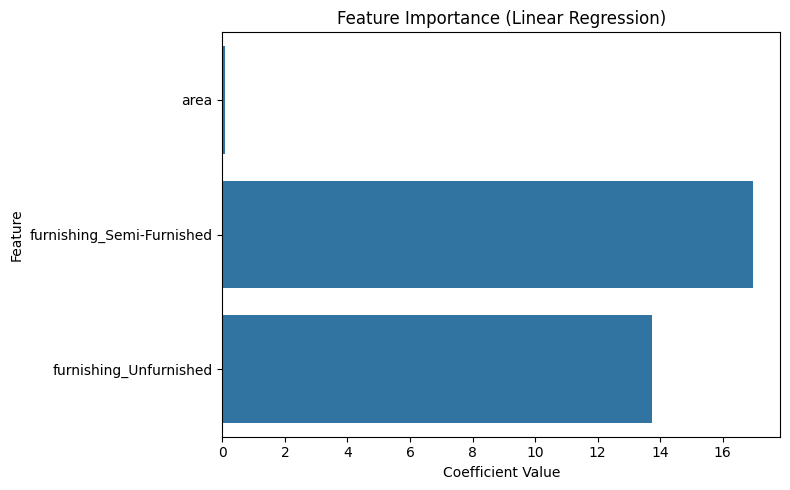

In [6]:
plt.figure(figsize=(8, 5))
sns.barplot(x=lr.coef_, y=X.columns)
plt.title("Feature Importance (Linear Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

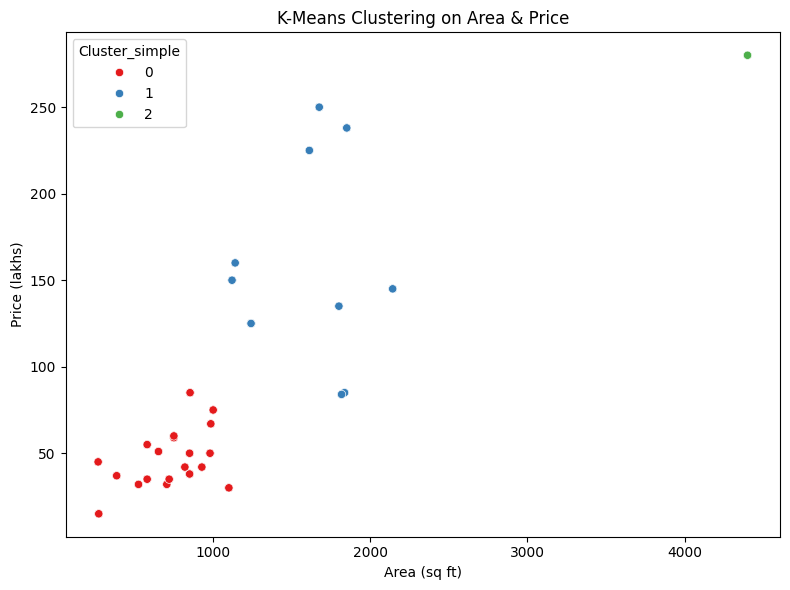

In [10]:
X_simple = df[['area', 'price']]
X_simple_scaled = StandardScaler().fit_transform(X_simple)

kmeans_simple = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster_simple'] = kmeans_simple.fit_predict(X_simple_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='area', y='price', hue='Cluster_simple', palette='Set1')
plt.title("K-Means Clustering on Area & Price")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price (lakhs)")
plt.tight_layout()
plt.show()
